In [762]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

import warnings
warnings.filterwarnings('ignore')

import math

In [763]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

train_data = train_data.drop(columns=['Unnamed: 0', 'Case_ID'])
test_data = test_data.drop(columns=['Unnamed: 0', 'Case_ID'])

In [764]:
train_data.columns

Index(['Grade', 'Gender', 'Age_at_diagnosis', 'Primary_Diagnosis', 'Race',
       'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1',
       'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4',
       'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA'],
      dtype='object')

In [765]:
train_data.isna().sum()

Grade                0
Gender               0
Age_at_diagnosis     0
Primary_Diagnosis    0
Race                 0
IDH1                 0
TP53                 0
ATRX                 0
PTEN                 0
EGFR                 0
CIC                  0
MUC16                0
PIK3CA               0
NF1                  0
PIK3R1               0
FUBP1                0
RB1                  0
NOTCH1               0
BCOR                 0
CSMD3                0
SMARCA4              0
GRIN2A               0
IDH2                 0
FAT4                 0
PDGFRA               0
dtype: int64

### Feature: Age_at_diagnosis

Фича содержит точные данные - возраст на момент постановки диагноза (с точностью до дней), округлим до месяца, при этом заменим пропуски (значения == '--') на моду всех полученных возрастов.

In [766]:
train_data[train_data.Age_at_diagnosis == '--']

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
138,LGG,Male,--,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
280,GBM,--,--,--,--,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [767]:
def change_age_feature(dataset_name):
    list_bad_age = []
    
    for i in range(dataset_name.shape[0]):
        if dataset_name.Age_at_diagnosis[i] != '--':
            if len(str(dataset_name.Age_at_diagnosis[i]).split(" ")) > 2:
                dataset_name.loc[i, 'Age_at_diagnosis'] = int(int(str(dataset_name.Age_at_diagnosis[i]).split(" ")[0]) + int(str(dataset_name.Age_at_diagnosis[i]).split(" ")[2])/365)
            else:
                dataset_name.loc[i, 'Age_at_diagnosis'] = int(str(dataset_name.Age_at_diagnosis[i]).split(" ")[0])
        else:
            list_bad_age.append(i)

    for pos in list_bad_age:
        moda = dataset_name.Age_at_diagnosis.value_counts().keys()[0]
        dataset_name.loc[pos, 'Age_at_diagnosis'] = moda
    

In [768]:
change_age_feature(train_data)
change_age_feature(test_data)

In [769]:
train_data

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,GBM,Male,79,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,Male,53,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,LGG,Female,61,"Astrocytoma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,Female,58,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,LGG,Male,30,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,GBM,Male,67,Glioblastoma,white,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
599,LGG,Female,27,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
600,LGG,Male,29,Mixed glioma,white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
601,LGG,Male,51,"Oligodendroglioma, anaplastic",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [770]:
train_data[train_data.Age_at_diagnosis == '--']

,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA


In [771]:
test_data[test_data.Age_at_diagnosis == '--']

,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA


In [772]:
train_data.Age_at_diagnosis.value_counts()

Age_at_diagnosis
54    21
58    18
53    17
61    16
63    16
      ..
80     1
17     1
88     1
87     1
89     1
Name: count, Length: 73, dtype: int64

### Gender

In [773]:
train_data = train_data[train_data.Gender != '--']
test_data.Gender[test_data.Gender == '--'] = 'Male'

train_data = train_data.reset_index()
test_data = test_data.reset_index()

In [774]:
train_data

,index,Grade,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,PTEN,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,GBM,Male,79,Glioblastoma,black or african american,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,1,LGG,Male,53,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,2,LGG,Female,61,"Astrocytoma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,3,LGG,Female,58,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,4,LGG,Male,30,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,598,GBM,Male,67,Glioblastoma,white,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
598,599,LGG,Female,27,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
599,600,LGG,Male,29,Mixed glioma,white,MUTATED,MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
600,601,LGG,Male,51,"Oligodendroglioma, anaplastic",white,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


# Delete some features

In [775]:
train_data = train_data[[ 'Grade', 'ATRX', 'PTEN', 'CIC']]     #  , 'RB1' ,'MUC16', 'PDGFRA', 'TP53', 'IDH2', 'GRIN2A'
test_data = test_data[['ATRX', 'PTEN', 'CIC']]                 #  , 'RB1', 'MUC16', 'PDGFRA', 'TP53', 'IDH2', 'GRIN2A'

# Encoder category features

In [776]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

label_encoder = LabelEncoder()

# cat_features = ['Gender', 'Primary_Diagnosis', 'Race', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16',
#        'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3',
#        'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

cat_features = ['ATRX', 'PTEN', 'CIC'] # , 'RB1', 'MUC16', 'RB1','MUC16', 'PDGFRA', 'TP53', 'IDH2', 'GRIN2A'

for feature in cat_features:
    train_data[feature]= label_encoder.fit_transform(train_data[feature])
    test_data[feature]= label_encoder.fit_transform(test_data[feature])

In [777]:
# train_data = train_data.drop(columns=['index'])
# test_data = test_data.drop(columns=['index'])

## TRAIN_TEST SPLIT

In [778]:
y_train = train_data.copy()

delete_columns = [column for column in y_train.columns if column != 'Grade']
y_train = y_train.drop(columns=delete_columns)

X_train = train_data.drop(columns='Grade')

In [779]:
y_train.value_counts()

Grade
LGG      349
GBM      253
Name: count, dtype: int64

In [780]:
y_train['Grade'] = y_train['Grade'].replace({'LGG': 0, 'GBM': 1})
y_train.Grade = y_train.Grade.astype('int32')

In [781]:
from sklearn.model_selection import train_test_split

X_new_train, X_valid, y_new_train, y_valid = \
    train_test_split(X_train, y_train, test_size=0.3, random_state=42)

In [782]:
print('X_new_train ', X_new_train.shape, 'y_new_train ', y_new_train.shape)
print('X_valid ', X_valid.shape, 'y_valid ', y_valid.shape)

X_new_train  (421, 3) y_new_train  (421, 1)
X_valid  (181, 3) y_valid  (181, 1)


# LazyPredict

In [783]:
from lazypredict.Supervised import LazyClassifier

# lazy_X_train , lazy_X_test , lazy_Y_train , lazy_Y_test = train_test_split(X_train , y_train, stratify=y_train, 
#                                                                            random_state = 5, 
#                                                                            test_size=0.30)

# clf = LazyClassifier(verbose=0,
#                      ignore_warnings=True,
#                      custom_metric=None,
#                      predictions=False,
#                      random_state=12,
#                      classifiers='all')

# lazy_models, lazy_predictions = clf.fit(lazy_X_train , lazy_X_test , lazy_Y_train , lazy_Y_test)

# lazy_models[:5]

# MODELS

In [784]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import f1_score

In [785]:
X_new_train = X_new_train.reset_index()
X_new_train = X_new_train.drop(columns=['index'])

X_valid = X_valid.reset_index()
X_valid = X_valid.drop(columns=['index'])

## Logistic Regression

In [786]:
logreg = LogisticRegression()
logreg.fit(X_new_train, y_new_train)

y_pred_logreg = logreg.predict(X_valid)

print(f1_score(y_valid, y_pred_logreg, average='macro'))

0.7230722154222766


## Decision tree

In [787]:
DecisionTree = DecisionTreeClassifier()
DecisionTree.fit(X_new_train, y_new_train)

y_pred_DecisionTree = DecisionTree.predict(X_valid)

print(f1_score(y_valid, y_pred_DecisionTree, average='macro'))

0.7230722154222766


## RandomForest

In [788]:
random_forest = RandomForestClassifier()
random_forest.fit(X_new_train, y_new_train)

y_pred_random_tree = random_forest.predict(X_valid)

print(f1_score(y_valid, y_pred_random_tree, average='macro'))

0.7230722154222766


## CatBoost

In [789]:
import catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

cat_boosting = CatBoostClassifier(verbose = False)

iters = [5, 10, 15, 20, 25, 35, 50]
learning_rate = [0.3, 0.1, 0.03, 0.01]
depth = [3, 4, 5, 6, 7]

params = {
    'iterations': iters,
    'learning_rate': learning_rate,
    'depth': depth,
}

In [790]:
cat_model = GridSearchCV(cat_boosting, params, cv=5, scoring='f1', verbose = 3)  #scoring='recall'

cat_model.fit(X_new_train, y_new_train)

print(cat_model.best_score_, cat_model.best_params_)

cat_boosting_model = CatBoostClassifier(
    iterations=cat_model.best_params_['iterations'],
    learning_rate=cat_model.best_params_['learning_rate'],
    max_depth=cat_model.best_params_['depth'],
   verbose=False)

cat_boosting_model.fit(X_new_train, y_new_train)

y_cat_pred = cat_boosting_model.predict(X_valid)

Fitting 5 folds for each of 140 candidates, totalling 700 fits
[CV 1/5] END depth=3, iterations=5, learning_rate=0.3;, score=0.720 total time=   0.0s
[CV 2/5] END depth=3, iterations=5, learning_rate=0.3;, score=0.769 total time=   0.0s
[CV 3/5] END depth=3, iterations=5, learning_rate=0.3;, score=0.759 total time=   0.0s
[CV 4/5] END depth=3, iterations=5, learning_rate=0.3;, score=0.778 total time=   0.0s
[CV 5/5] END depth=3, iterations=5, learning_rate=0.3;, score=0.735 total time=   0.0s
[CV 1/5] END depth=3, iterations=5, learning_rate=0.1;, score=0.720 total time=   0.0s
[CV 2/5] END depth=3, iterations=5, learning_rate=0.1;, score=0.769 total time=   0.0s
[CV 3/5] END depth=3, iterations=5, learning_rate=0.1;, score=0.759 total time=   0.0s
[CV 4/5] END depth=3, iterations=5, learning_rate=0.1;, score=0.778 total time=   0.0s
[CV 5/5] END depth=3, iterations=5, learning_rate=0.1;, score=0.735 total time=   0.0s
[CV 1/5] END depth=3, iterations=5, learning_rate=0.03;, score=0.72

In [791]:
print(f1_score(y_valid, y_cat_pred, average='micro'))

0.712707182320442


# XGBoost

In [792]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from math import sqrt

xg_boosting = XGBClassifier(eval_metric='logloss', use_label_encoder=False)   # subsample=0.66, gamma=0.001


n_estimators = [5, 10, 15, 20, 30, 40, 50, 60, 75, 100]
learning_rate = [0.05, 0.1, 0.15, 0.2]
min_child_weight = [5, 6, 7, 8]
max_depth = [5, 6, 7]
gamma = [0.001, 0.01]
subsample = [0.5, 0.66]


params = {
    'n_estimators': n_estimators,
    'learning_rate': learning_rate,
    'max_depth': max_depth,
    
    # 'min_child_weight': min_child_weight, 
    # 'gamma': gamma,
    # 'subsample': subsample, 
}

In [793]:
model = GridSearchCV(xg_boosting, params, cv=10, scoring='f1', verbose=3)

model.fit(X_new_train, y_new_train)

model.best_params_

Fitting 10 folds for each of 120 candidates, totalling 1200 fits
[CV 1/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.538 total time=   0.0s
[CV 2/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.593 total time=   0.0s
[CV 3/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.500 total time=   0.0s
[CV 4/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.606 total time=   0.0s
[CV 5/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.483 total time=   0.0s
[CV 6/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.348 total time=   0.0s
[CV 7/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.273 total time=   0.0s
[CV 8/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.480 total time=   0.0s
[CV 9/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.500 total time=   0.0s
[CV 10/10] END learning_rate=0.05, max_depth=5, n_estimators=5;, score=0.571 tot

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 20}

In [794]:
y_pred = model.predict(X_valid)

In [795]:
xg_boosting_model = XGBClassifier(
    n_estimators=model.best_params_['n_estimators'],
    learning_rate=model.best_params_['learning_rate'],
    max_depth=model.best_params_['max_depth']
    )

xg_boosting_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

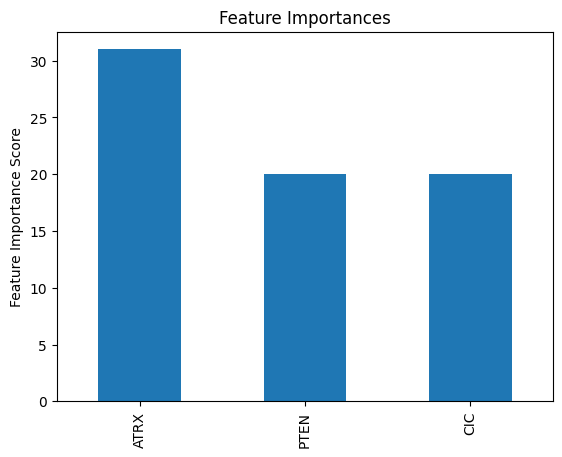

In [796]:
feat_imp = pd.Series(xg_boosting_model.get_booster().get_fscore()).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importances')
plt.ylabel('Feature Importance Score')
pass

# Final predictions

In [797]:
test_data = test_data.reset_index()
test_data = test_data.drop(columns=['index'])

In [798]:
test_data

,ATRX,PTEN,CIC
0,0,1,1
1,1,1,1
2,1,1,1
3,1,0,1
4,1,1,1
...,...,...,...
254,0,1,1
255,1,1,0
256,0,1,1
257,1,1,1


In [805]:
y_pred_final = cat_boosting_model.predict(test_data)

In [806]:
y_pred_final

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0], dtype=int64)

In [801]:
sample_submission_file = pd.read_csv('sample_submission_file.csv')
sample_submission_file

,Id,Grade
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
254,254,0
255,255,0
256,256,0
257,257,0


In [802]:
for i in range(len(y_pred_final)):
    sample_submission_file.loc[i, 'Grade'] = y_pred_final[i]

In [803]:
sample_submission_file

,Id,Grade
0,0,0
1,1,0
2,2,0
3,3,1
4,4,0
...,...,...
254,254,0
255,255,0
256,256,0
257,257,0


In [804]:
sample_submission_file.to_csv('result.csv', index=False)